# Model Design — An Agent-Based Model of Central Clearing

**MSc thesis · client clearing, contagion and CCP systemic risk.**

### The question
A central counterparty (CCP) stands between buyers and sellers so that one trader's default
doesn't directly hit its counterparties. But most end-users don't face the CCP directly —
they **clear through a clearing member (CM)**, a bank or broker that guarantees their trades.
This tiering is the focus: *does clearing clients through CMs change how — and how badly — a
market stress propagates?* Concretely: when a client defaults, does the loss stay with its
CM, or cascade on to the CCP and the other members (mutualisation)? And what governs which?

### The approach — a two-tier model
1. **Market-microstructure layer.** A limit order book where **fundamental** (value),
   **momentum** (trend) and **zero-intelligence** (noise) traders trade ES S&P-500 futures
   around an exogenous, real-data fundamental. It is *calibrated* to reproduce the empirical
   ES stylised facts (fat tails, volatility clustering, no return autocorrelation), so the
   price/volume environment the clearing layer acts in is realistic, not assumed.
2. **Central-clearing layer**, on top. A CCP, **banking CMs** (which also trade their own
   book) and **non-banking CMs** (pure intermediaries), each clearing a book of clients.
   Real margin machinery: procyclical VaR initial margin, USD variation margin, a cover-2
   default fund, a five-level loss waterfall, and Almgren–Chriss fire-sales. Clients and CMs
   post margin from their own cash, can be margin-called, freeze, and default — and losses
   flow **client → CM → CCP → surviving members**.

### The headline result (run on the *real* COVID crash)
At true COVID severity the cover-2 framework **contains** client defaults — the defaulter's
own margin and default-fund layers absorb them, with no spill to other members. A
**reverse-stress** sweep then shows cross-member **mutualisation only onsets at ≈2.5× COVID**,
with the CCP solvent throughout. So the framework behaves as a sound CCP should, and we can
quantify exactly how far beyond COVID it takes to break it (§6–§8).

Run all cells to regenerate every figure from the current model. Figures use a **calm** 2019
regime and the **stressed** 2020 COVID window (overnight gaps retained, so it carries the
true ≈−33% drawdown).

## 1 · Model at a glance

| | |
|---|---|
| **Asset** | E-mini S&P 500 (ES front-month), 0.25 tick, 1-min call auction; real RTH sessions ≈405 bars and variable, boundaries read from the data (D57) |
| **Regimes** | calm (2019) · stressed (COVID crash, Feb–Apr 2020) |
| **Fundamental** | exogenous Kalman-filtered real efficient price of the ES mid, overnight gaps retained (D56); jump-diffusion SV path kept as an alternative — §10 |
| **Market agents** | 30 fundamental + 10 banking-CM (FT-cast) + 20 momentum + 40 zero-intelligence = 100 on the book |
| **Clearing tier** | 1 CCP + 10 BCM + 5 NBCM; procyclical VaR margin, cover-2 SLOIM default fund, deficit-based 5-level waterfall |
| **Client clearing** | 90 clients (FT/MT/ZI) clear through the CMs, 5–15 per CM (skewed); a client default cascades to its CM — the contagion channel |
| **Volume / cash** | per-regime `VOLUME_LOT` matches empirical ES volume; CM/client cash from CFTC/LCH disclosures |

The market layer is calibrated by matching simulated 1-minute return moments to
empirical ES moments, via **both** a surrogate-assisted SMM and an exhaustive
grid search (the two cross-validate; §10). The clearing layer then runs on top.

*Note: the client population was scaled 2× while **preserving** the price-formation
mix (FT-equiv : MT : ZI = 40 : 20 : 40, identical to before), so the existing
calibrated parameters carry over; a full re-calibration is planned to finalise them.*

## 2 · Agents, margins and the waterfall

**Market layer (per-minute, ODD-native Bernoulli rates).** *Fundamental traders*
hold a fixed belief `z~N(0,1)` and quote a reservation `V_t + z·ft_sigma_c·σ_t·v0`
(persistent `z` builds the concentrated inventories the clearing layer acts on).
*Momentum traders* follow an EWMA trend (limit-only). *Zero-intelligence traders*
post/cancel/market-order at calibrated rates (geometric placement depth fit from
real L2 book data). The market maker and volatility trader were removed (ablation).

**Clearing layer (margin methodology grounded in real CCP practice, D55).** Banking
clearing members (FT subclass) trade own-account *and* clear a client book; non-banking
CMs are pure intermediaries; FT/MT/ZI clients clear through them. Every 60 minutes the
**variation-margin cycle** marks the cleared book to market in USD
(`× VOLUME_LOT × CONTRACT_USD`) and settles it into CM cash. **Initial margin is a
procyclical VaR/SPAN scan** (99% / 2-day VaR floored by an anti-procyclicality floor
≈ the CME ES margin: ≈6% calm rising to ≈12% stressed). The **capital ratio is
cash / initial margin** (CFTC Reg 1.17 — adjusted net capital ≥ 8% of *risk margin*,
not gross notional); a CM breaching the 8% floor **deleverages via Almgren-Chriss**
(BCM fire-sale; NBCM stops out and freezes its clients). A BCM's own (house) book is
capped by a **VaR risk limit** (Basel FRTB) so it cannot accumulate an unbounded prop
position. On a **default** (cash ≤ 0) the CCP runs the **5-level waterfall** on the
member's realised **cash deficit** (defaulted-member DF → exchange SITG → pooled member
DF → surviving-CM cash → exchange) and fire-sells the book (AC) — the price impact
transmits the default to surviving members. The **default fund** is a cover-2
**Stress-Loss-Over-Initial-Margin** fund (Euronext Clearing module A9): the two
most-exposed members' loss *above posted margin* under an extreme-but-plausible move,
× (1 + 10% buffer).

**Client clearing (the contagion channel).** Each client carries its own balance sheet
and clears through a CM. The margin cycle issues each client its own variation-margin
call, paid from its **own cash** (the CM relays it to the CCP). A client can only open
what its cash can margin against a fixed **house margin** (20%, 5× leverage, uniform);
as variation-margin losses erode that cash it **freezes** at the 8% floor (stops trading)
and **defaults** at zero. On a client default the **CM assumes and liquidates** the
position: it covers the uncollected margin and disposes of the inherited book via
Almgren-Chriss (BCM sends its own orders; the NBCM's are routed by the CCP), the close-out
loss realised by **marking the assumed position as the fire-sale walks the price**
(deficit-consistent — no flat haircut). This drains CM cash and can topple the CM: the
client → CM → CCP cascade, the thesis's central contagion mechanism. A non-banking CM
fails purely through client defaults; a banking CM through that *or* its own book.

## 0 · Fundamental toggle — data-derived vs simulated $V_t$

The simulator is driven by an exogenous fundamental $V_t$. A switch at the top of the setup
cell, **`FV_MODE`**, selects which one — everything downstream (calibrated θ, the clearing
tier, every figure) is identical; only $V_t$ changes:

- **`"kalman"`** (default — the headline model): the **data-derived** Kalman-smoothed real ES
  mid (`data/v_kalman.py`; D57 real ≈405-bar sessions, overnight gaps retained). $V_t$ is the
  real price with microstructure noise filtered out, so the simulated mid tracks the *actual*
  ES path.
- **`"simulated"`**: the **synthetic** Stein–Stein/Heston stochastic-volatility + Merton-jump
  path (`data/v_gbm.py`, §10). It carries the same *volatility regime* as the data but is a
  **random path**, not the real episode — so the price overlay will not track real ES, and the
  "stressed" path is a high-vol random walk rather than the COVID crash itself. The question it
  answers is robustness: *does the agent layer still reproduce the ES stylised facts (fat tails,
  volatility clustering, no return autocorrelation) on an independent fundamental?*

Flip `FV_MODE` and re-run the notebook to switch.

In [19]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

from model.globals import (ModelParams, V0, CALIBRATED, VOLUME_LOT, CONTRACT_USD,
                           CCP_CALIBRATION, SIGMA_V, im_fraction, FV_CSV)
from model.agents import (FundamentalTrader, MomentumTrader,
                          ZeroIntelligenceTrader, BankingClearingMember,
                          NonBankingClearingMember)
from model.simulation import Simulation
from run_simulation import build_traders, build_clearing_tier, BARS_PER_DAY

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})
PROC = Path("data/processed")
N_DAYS = {"calm": 30, "stressed": 29}     # stressed ~= full COVID window; calm is the
                                          # stationary regime, run a comparable window

# ── Fundamental toggle (see §0) ───────────────────────────────────────────────
# "kalman"    = data-derived Kalman-smoothed real ES mid (primary; data/v_kalman.py)
# "simulated" = synthetic Stein-Stein/Heston SV + Merton-jump path (data/v_gbm.py, §10)
FV_MODE = "kalman"          # <-- flip to "simulated" to drive the model on the synthetic V_t
FV_FILE = {
    "kalman":    {r: FV_CSV[r]              for r in ("calm", "stressed")},
    "simulated": {r: f"data/fv_gbm_{r}.csv" for r in ("calm", "stressed")},
}
def fv_path(regime): return FV_FILE[FV_MODE][regime]

def run_regime(regime, seed=42):
    p = ModelParams(n_fundamental=30, n_momentum=20, n_momentum_long=0,
                    n_mm=0, n_zi=40, n_vt=0, n_ct=0,
                    n_bcm=10, n_nbcm=5, n_bcm_with_clients=5,
                    v0=V0[regime], tick_size=0.25, dt_minutes=1.0,
                    fv_csv=fv_path(regime),
                    **CALIBRATED[regime], stressed=(regime == "stressed"))
    traders = build_traders(p, seed=seed)
    ccp = build_clearing_tier(traders, p, seed=seed)
    sim = Simulation(p, traders, seed=seed, ccp=ccp)
    hist = pd.DataFrame(sim.run(BARS_PER_DAY * N_DAYS[regime]))
    clearing = pd.DataFrame(sim.clearing_history)
    return dict(params=p, traders=traders, ccp=ccp, sim=sim, hist=hist, clearing=clearing)

def emp_returns(regime):
    df = pd.read_csv(PROC / f"ES_front_{regime}_1m.csv", parse_dates=["ts"])
    df["date"] = df["ts"].dt.date
    parts = [np.diff(np.log(s[s > 0].values))
             for _, s in df.groupby("date")["mid"] if len(s) > 1]
    return np.concatenate(parts)

# Session opens of the ACTIVE fundamental, read from its own `ts` (D57: data-driven).
# Under "kalman" these are the real ≈405-bar sessions; under "simulated" the synthetic
# 390-bar days. The sim runs without v_start here, so step t aligns row-for-row with fv row t.
def fv_opens(regime):
    ts = pd.read_csv(fv_path(regime), usecols=["ts"], parse_dates=["ts"])["ts"]
    d = ts.dt.normalize().to_numpy()
    return [int(i) for i in np.flatnonzero(np.r_[True, d[1:] != d[:-1]])]

def real_opens(regime, n=None):
    return [d for d in fv_opens(regime) if d > 0 and (n is None or d < n)]

def day_of(regime, t):                # 0-based session index of each step t
    s = np.asarray(fv_opens(regime))
    return np.searchsorted(s, np.asarray(t), side="right") - 1

def sim_returns(hist, regime):
    m = pd.Series(hist["mid_price"]).ffill().to_numpy(); m = m[m > 0]
    r = np.diff(np.log(m))            # drop overnight (day-boundary) returns (D56/D57)
    return np.delete(r, [d - 1 for d in real_opens(regime, len(m))])

def real_mid_spliced(regime):
    # The REAL ES mid at its REAL per-day levels — overnight gaps PRESERVED (D56),
    # exactly as data/v_kalman.py now builds V_smooth — so this raw real mid is
    # row-aligned, in the same level, to the gapped Kalman fundamental and the
    # simulated mid. The only difference from the fundamental is the RTS smoothing,
    # so overlaying the two shows directly that V_t is the *smoothed* real price
    # (less noisy, not more). Presentation follows XGB-Chiarella (2208.14207) §2.5.2.
    df = pd.read_csv(PROC / f"ES_front_{regime}_1m.csv", parse_dates=["ts"])
    df["date"] = df["ts"].dt.date
    parts = [np.log(s["mid"][s["mid"] > 0].values) for _, s in df.groupby("date")]
    return np.exp(np.concatenate([p for p in parts if len(p)]))

REGIMES = ["calm", "stressed"]
SIM = {r: run_regime(r) for r in REGIMES}
EMP = {r: emp_returns(r) for r in REGIMES}
RET = {r: sim_returns(SIM[r]["hist"], r) for r in REGIMES}
REAL = {r: real_mid_spliced(r) for r in REGIMES}
for r in REGIMES:
    h = SIM[r]["hist"]; cl = SIM[r]["clearing"]
    nd = int(cl[cl.has_defaulted].agent_id.nunique()) if len(cl) else 0
    print(f"{r:9s} {len(h):6d} steps | contracts/min {h['volume'].mean()*VOLUME_LOT[r]:6.0f} "
          f"(emp {EMP[r].std():.1e} vs sim {RET[r].std():.1e}) | defaulted CMs {nd}")

calm       11700 steps | contracts/min   2368 (emp 3.0e-04 vs sim 2.9e-04) | defaulted CMs 0
stressed   11310 steps | contracts/min   4009 (emp 1.8e-03 vs sim 1.2e-03) | defaulted CMs 0


## 3 · Agent topology (the clearing star)

The central hub is the CCP and the exchange/LOB combined. Each spoke is a clearing member;
the orange dots and the number on each node are its **actual** cleared client count, so the
figure shows the real **skewed** books. The 90 clients (30 FT + 20 MT + 40 ZI) are spread
**5–15 per CM**, with the **non-banking CMs holding the largest books** (pure intermediaries
— all their capacity is client-clearing) and the client-banking CMs fewer; the other five
BCMs are own-account only (no dots). Within each type, the larger CMs (by cash) clear more.
A bigger book = more concentrated client-default risk.

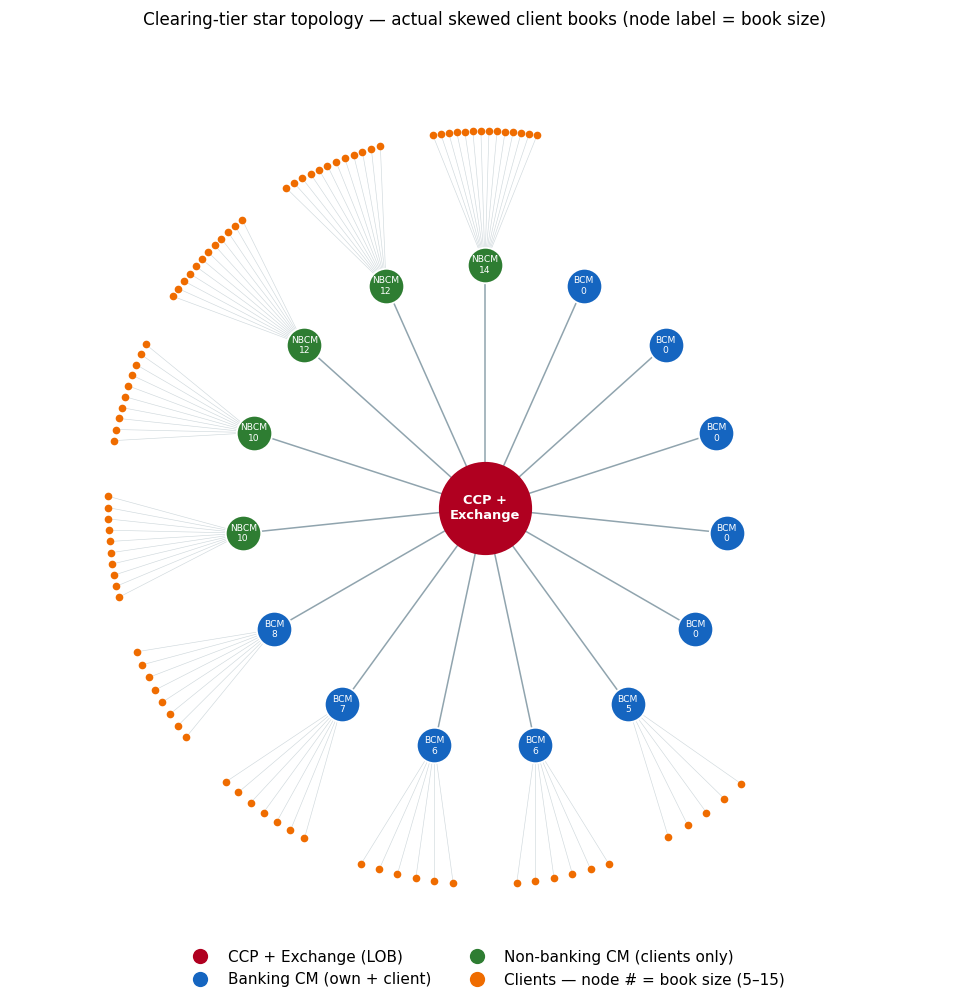

In [20]:
ccp = SIM["calm"]["ccp"]
mem = sorted(ccp.members.values(),
             key=lambda m: (isinstance(m, NonBankingClearingMember), len(m.client_ids)), reverse=True)
fig, ax = plt.subplots(figsize=(9.2, 9.2)); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Clearing-tier star topology — actual skewed client books (node label = book size)", fontsize=11)
ax.scatter([0], [0], s=3600, c="#b00020", zorder=5)
ax.text(0, 0, "CCP +\nExchange", ha="center", va="center", color="white", fontsize=8.5, weight="bold", zorder=6)
for k, cm in enumerate(mem):
    ang = 2*np.pi*k/len(mem) + np.pi/2
    x, y = np.cos(ang), np.sin(ang)
    ax.plot([0, x], [0, y], color="#90a4ae", lw=1.0, zorder=1)
    is_n = isinstance(cm, NonBankingClearingMember)
    col = "#2e7d32" if is_n else "#1565c0"; kind = "NBCM" if is_n else "BCM"
    n = len(cm.client_ids)
    ax.scatter([x], [y], s=540, c=col, zorder=4, edgecolors="white", linewidths=1.2)
    ax.text(x, y, f"{kind}\n{n}", ha="center", va="center", color="white", fontsize=6.0, zorder=6)
    for c in range(n):                                   # one dot per ACTUAL client
        cang = ang + (c - (n - 1) / 2) * (0.30 / max(n, 1))
        cx, cy = 1.55*np.cos(cang), 1.55*np.sin(cang)
        ax.plot([x, cx], [y, cy], color="#cfd8dc", lw=0.4, zorder=1)
        ax.scatter([cx], [cy], s=16, c="#ef6c00", zorder=3)
from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c, markersize=11, label=l)
       for c, l in [("#b00020","CCP + Exchange (LOB)"), ("#1565c0","Banking CM (own + client)"),
                    ("#2e7d32","Non-banking CM (clients only)"), ("#ef6c00","Clients — node # = book size (5–15)")]]
ax.legend(handles=leg, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
ax.set_xlim(-1.95, 1.95); ax.set_ylim(-1.95, 1.95)
plt.tight_layout(); plt.show()

## 4 · Price formation, volume and the intraday fundamental–mid relationship

Each price panel overlays three series on the same axes (after XGB-Chiarella
2208.14207 §2.5.2, which plots the simulated price against the real series):

- **real ES mid** (grey) — the raw observed 1-minute mid at real levels (overnight gaps retained, D56);
- **fundamental $V_t$** (red) — the *Kalman-smoothed* real mid the simulator is
  driven by (`data/v_kalman.py`); it is the same series as the real mid with the
  microstructure noise filtered out, so it is **less** noisy, not more;
- **simulated mid** (blue) — the emergent model price.

The simulated mid tracks $V_t$ while the agent flow adds its own microstructure
noise around it. The intraday zooms below (one real RTH session per regime — sessions
are ≈405 bars and vary, read from the data, D57; the stressed panel zooms a crash-window
day) show the tracking, the real-vs-smoothed gap,
and the simulated bid-ask bounce clearly. The simulator opens each session at the
gapped $V_t$ (a clean between-session reprice of the book), and the overnight
boundary return is excluded from the calibration moments at those real boundaries —
matching the empirical intraday convention — so the gaps stress the cleared book
without contaminating the stylised-fact fit.

The final 2×2 set tracks **book depth** (resting bid/ask volume, in contracts), the
**buy/sell depth ratio** (bid ÷ ask — book imbalance / which side thins), and **margin
calls per day**: in the stressed regime the book **thins** — less resting liquidity, as
fundamental traders widen their quotes and cleared clients freeze / deleverage — the
buy/sell ratio drifts from 1, and margin calls spike (the procyclical pressure driving
the clearing dynamics).

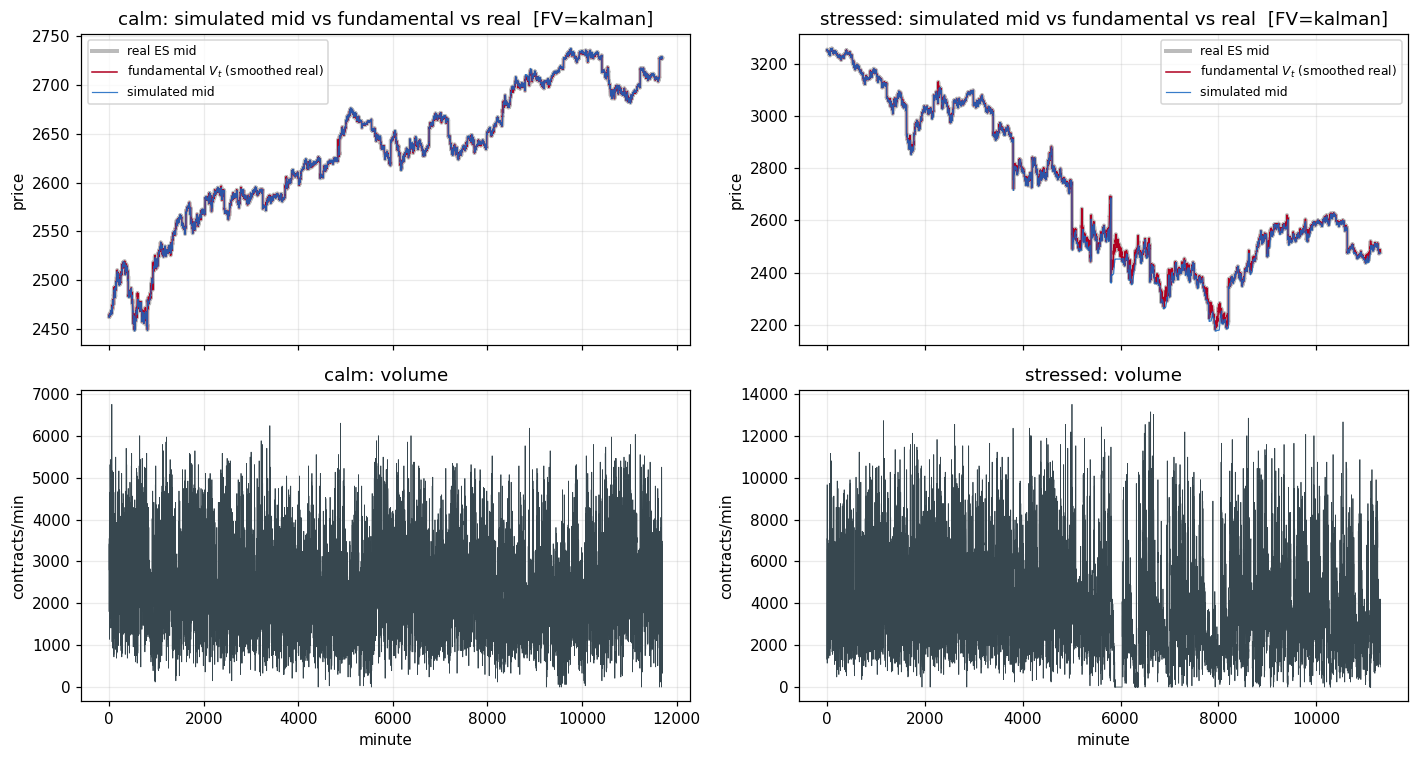

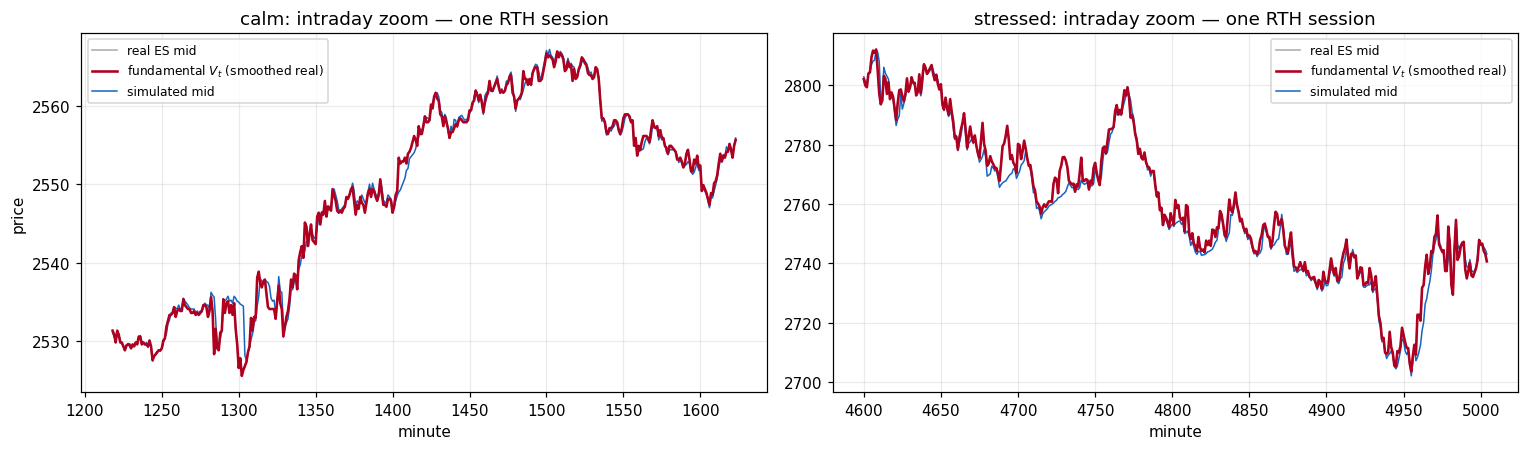

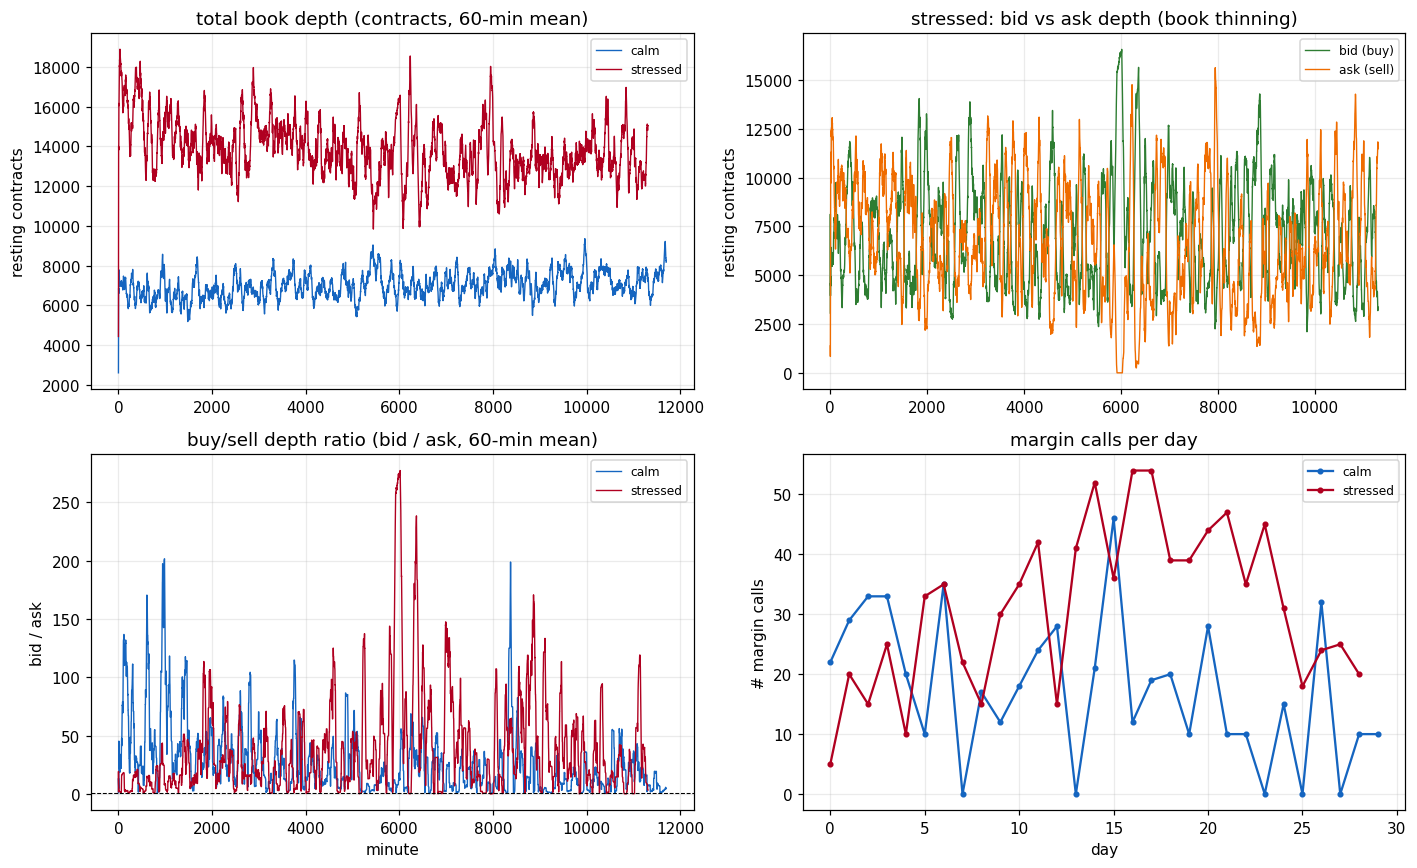

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex="col")
for j, r in enumerate(REGIMES):
    h = SIM[r]["hist"]; t = h["t"].to_numpy()
    rm = REAL[r][:len(t)]
    # The fundamental V_t IS the Kalman-smoothed real mid, so it sits almost exactly
    # on the real series — draw the real mid THICK underneath (a grey halo) so it
    # stays visible rather than fully hidden under the red; the simulated mid on top
    # shows the model tracking both (the close overlap at this macro scale IS the
    # result — that the model reproduces the real path; the intraday zoom below shows
    # where they differ). Under FV_MODE="simulated" V_t is a synthetic path, so it and the
    # simulated mid will NOT track the grey real ES — that divergence is expected.
    _fvlbl = ("fundamental $V_t$ (smoothed real)" if FV_MODE == "kalman"
              else "fundamental $V_t$ (synthetic SV-jump)")
    axes[0, j].plot(t[:len(rm)], rm, color="#9e9e9e", lw=2.6, alpha=0.7, zorder=1, label="real ES mid")
    axes[0, j].plot(t, h["fundamental"], color="#b00020", lw=1.0, zorder=2, label=_fvlbl)
    axes[0, j].plot(t, pd.Series(h["mid_price"]).ffill(), color="#1565c0", lw=0.8, alpha=0.85, zorder=3, label="simulated mid")
    axes[0, j].set_title(f"{r}: simulated mid vs fundamental vs real  [FV={FV_MODE}]"); axes[0, j].legend(fontsize=8)
    axes[0, j].set_ylabel("price")
    axes[1, j].plot(t, h["volume"]*VOLUME_LOT[r], color="#37474f", lw=0.5)
    axes[1, j].set_title(f"{r}: volume"); axes[1, j].set_xlabel("minute"); axes[1, j].set_ylabel("contracts/min")
plt.tight_layout(); plt.show()

# Intraday zoom — ONE real RTH session per regime: real mid vs V_t vs simulated mid
# (a real session is ~405 bars and varies, so slice between consecutive real opens — D57).
# Stressed zooms a crash-window session so the intraday dynamics under stress are visible.
ZOOM = {"calm": 2, "stressed": 11}
_fvz = ("fundamental $V_t$ (smoothed real)" if FV_MODE == "kalman"
        else "fundamental $V_t$ (synthetic SV-jump)")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, r in zip(axes, REGIMES):
    h = SIM[r]["hist"]; op = real_opens(r); k = min(ZOOM[r], len(op) - 2)
    day = slice(op[k], op[k + 1])
    ax.plot(h["t"][day], REAL[r][day], color="#9e9e9e", lw=1.1, alpha=0.8, zorder=1, label="real ES mid")
    ax.plot(h["t"][day], h["fundamental"][day], color="#b00020", lw=1.7, zorder=3, label=_fvz)
    ax.plot(h["t"][day], pd.Series(h["mid_price"]).ffill()[day], color="#1565c0", lw=1.0, zorder=2, label="simulated mid")
    ax.set_title(f"{r}: intraday zoom — one RTH session"); ax.set_xlabel("minute"); ax.legend(fontsize=8)
axes[0].set_ylabel("price")
plt.tight_layout(); plt.show()

# Book depth (resting bid/ask volume), buy/sell ratio, and margin-call pressure.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for r, c in zip(REGIMES, ["#1565c0", "#b00020"]):
    h = SIM[r]["hist"]
    tot = ((h["bid_depth"] + h["ask_depth"]) * VOLUME_LOT[r]).rolling(60, min_periods=1).mean()
    axes[0, 0].plot(h["t"], tot, color=c, lw=0.9, label=r)
axes[0, 0].set_title("total book depth (contracts, 60-min mean)")
axes[0, 0].set_ylabel("resting contracts"); axes[0, 0].legend(fontsize=8)
hs = SIM["stressed"]["hist"]; vl = VOLUME_LOT["stressed"]
axes[0, 1].plot(hs["t"], (hs["bid_depth"]*vl).rolling(60, min_periods=1).mean(), color="#2e7d32", lw=0.9, label="bid (buy)")
axes[0, 1].plot(hs["t"], (hs["ask_depth"]*vl).rolling(60, min_periods=1).mean(), color="#ef6c00", lw=0.9, label="ask (sell)")
axes[0, 1].set_title("stressed: bid vs ask depth (book thinning)")
axes[0, 1].set_ylabel("resting contracts"); axes[0, 1].legend(fontsize=8)
for r, c in zip(REGIMES, ["#1565c0", "#b00020"]):
    h = SIM[r]["hist"]
    ratio = ((h["bid_depth"] + 1) / (h["ask_depth"] + 1)).rolling(60, min_periods=1).mean()
    axes[1, 0].plot(h["t"], ratio, color=c, lw=0.9, label=r)
axes[1, 0].axhline(1.0, color="k", lw=0.7, ls="--")
axes[1, 0].set_title("buy/sell depth ratio (bid / ask, 60-min mean)")
axes[1, 0].set_xlabel("minute"); axes[1, 0].set_ylabel("bid / ask"); axes[1, 0].legend(fontsize=8)
for r, c in zip(REGIMES, ["#1565c0", "#b00020"]):
    cl = SIM[r]["clearing"]
    if len(cl):
        calls = cl.groupby(day_of(r, cl.t.to_numpy())).call_indicator.sum()
        axes[1, 1].plot(calls.index, calls.values, color=c, marker="o", ms=3, label=r)
axes[1, 1].set_title("margin calls per day"); axes[1, 1].set_xlabel("day"); axes[1, 1].set_ylabel("# margin calls"); axes[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5 · Demand and inventory concentration

Persistent heterogeneous beliefs make high-`z` fundamental traders accumulate
longs and low-`z` ones shorts — aggregate demand resolves into a spread of
concentrated inventories, which is what the clearing layer's margin and default
mechanics act on.

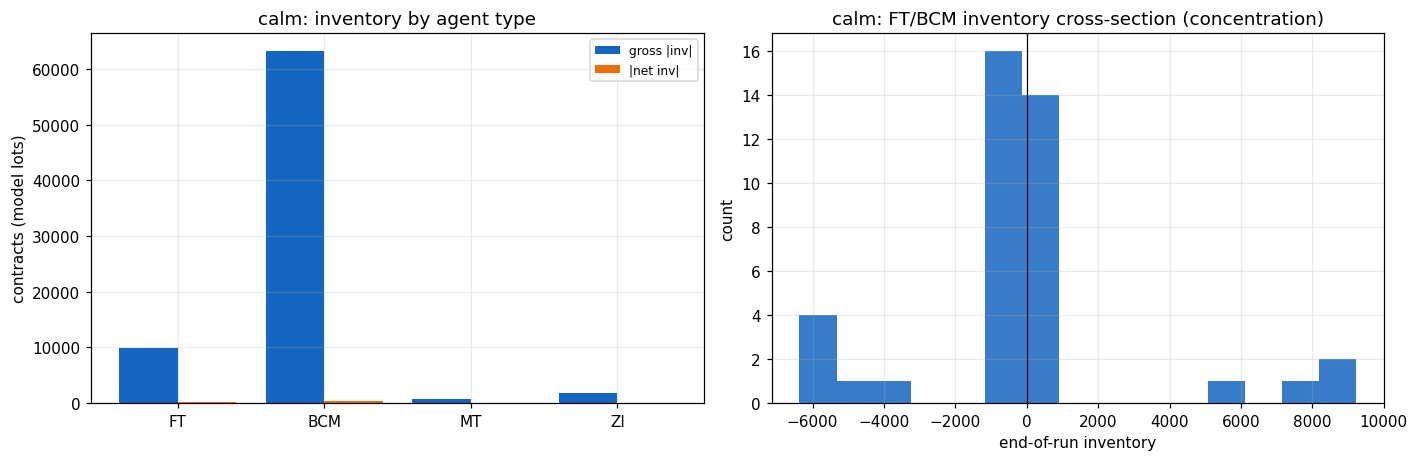

In [22]:
def classify(t):
    if isinstance(t, BankingClearingMember): return "BCM"
    if isinstance(t, FundamentalTrader): return "FT"
    if isinstance(t, MomentumTrader): return "MT"
    if isinstance(t, ZeroIntelligenceTrader): return "ZI"
    return "other"
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
tr = SIM["calm"]["traders"]; inv = {}
for t in tr: inv.setdefault(classify(t), []).append(t.inventory)
types = ["FT", "BCM", "MT", "ZI"]; x = np.arange(len(types))
axes[0].bar(x-0.2, [np.sum(np.abs(inv.get(k,[0]))) for k in types], 0.4, label="gross |inv|", color="#1565c0")
axes[0].bar(x+0.2, [abs(np.sum(inv.get(k,[0]))) for k in types], 0.4, label="|net inv|", color="#ef6c00")
axes[0].set_xticks(x); axes[0].set_xticklabels(types); axes[0].legend(fontsize=8)
axes[0].set_title("calm: inventory by agent type"); axes[0].set_ylabel("contracts (model lots)")
ftbcm = inv.get("FT",[]) + inv.get("BCM",[])
axes[1].hist(ftbcm, bins=15, color="#1565c0", alpha=0.85); axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("calm: FT/BCM inventory cross-section (concentration)")
axes[1].set_xlabel("end-of-run inventory"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

## 6 · Clearing tier — capital ratios, cash and variation margin (stressed)

The stressed run is where the clearing dynamics fire. Each line is one clearing
member over the COVID window: the capital ratio against the 8% floor, the cash
trajectory, and cumulative variation margin. Crosses mark defaults.

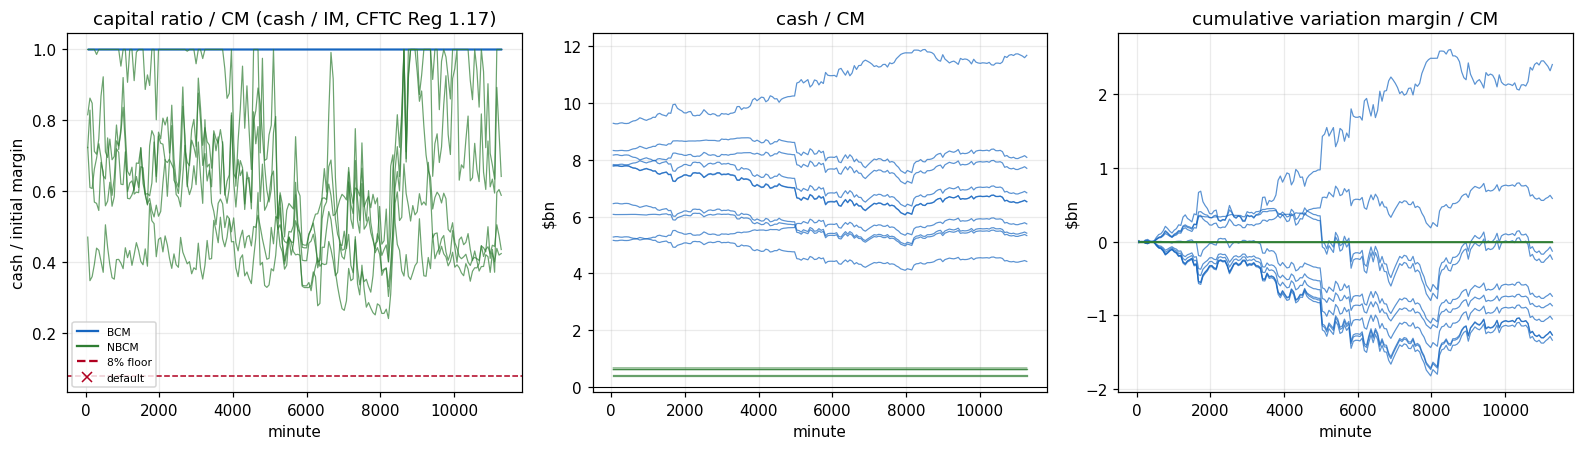

In [23]:
r = "stressed"; cl = SIM[r]["clearing"]
deftimes = cl[cl.has_defaulted].groupby("agent_id").t.min().to_dict()
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
for aid, g in cl.groupby("agent_id"):
    col = "#1565c0" if g["kind"].iloc[0] == "BCM" else "#2e7d32"
    axes[0].plot(g.t, g.capital_ratio.clip(-0.1, 1.0), color=col, lw=0.8, alpha=0.7)
    axes[1].plot(g.t, g.cash/1e9, color=col, lw=0.8, alpha=0.7)
    axes[2].plot(g.t, g.vm_cumulative/1e9, color=col, lw=0.8, alpha=0.7)
    if aid in deftimes:
        td = deftimes[aid]; row = g[g.t == td]
        axes[0].plot(td, float(row.capital_ratio.clip(-0.1,1.0).iloc[0]), "x", color="#b00020", ms=8, mew=2)
axes[0].axhline(CCP_CALIBRATION["cap_ratio_floor"], color="#b00020", ls="--", lw=1, label="8% floor")
axes[0].set_title("capital ratio / CM (cash / IM, CFTC Reg 1.17)"); axes[0].set_ylabel("cash / initial margin"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="k", lw=0.7); axes[1].set_title("cash / CM"); axes[1].set_ylabel("$bn")
axes[2].set_title("cumulative variation margin / CM"); axes[2].set_ylabel("$bn")
for a in axes: a.set_xlabel("minute")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([0],[0],color="#1565c0",label="BCM"),
                        Line2D([0],[0],color="#2e7d32",label="NBCM"),
                        Line2D([0],[0],color="#b00020",ls="--",label="8% floor"),
                        Line2D([0],[0],marker="x",color="#b00020",ls="",label="default")], fontsize=7)
plt.tight_layout(); plt.show()

## 7 · Defaulted members — stats and descriptors

Per defaulted clearing member: when it failed, its capital ratio (cash / IM) and cash
at default, the size of its cleared book (gross USD exposure ≈ IM / im_fraction(σ)), and
the deepest waterfall level reached to absorb its **cash deficit**. The default-fund
summary and the waterfall-level distribution follow.

================  CALM  ================
defaults: 0  (0 BCM, 0 NBCM)   | cover-2 total_DF $7.4B  SITG end $0.74B  CCP cash end $7.50B (start $7.5B)

================  STRESSED  ================
defaults: 0  (0 BCM, 0 NBCM)   | cover-2 total_DF $0.6B  SITG end $0.06B  CCP cash end $7.50B (start $7.5B)



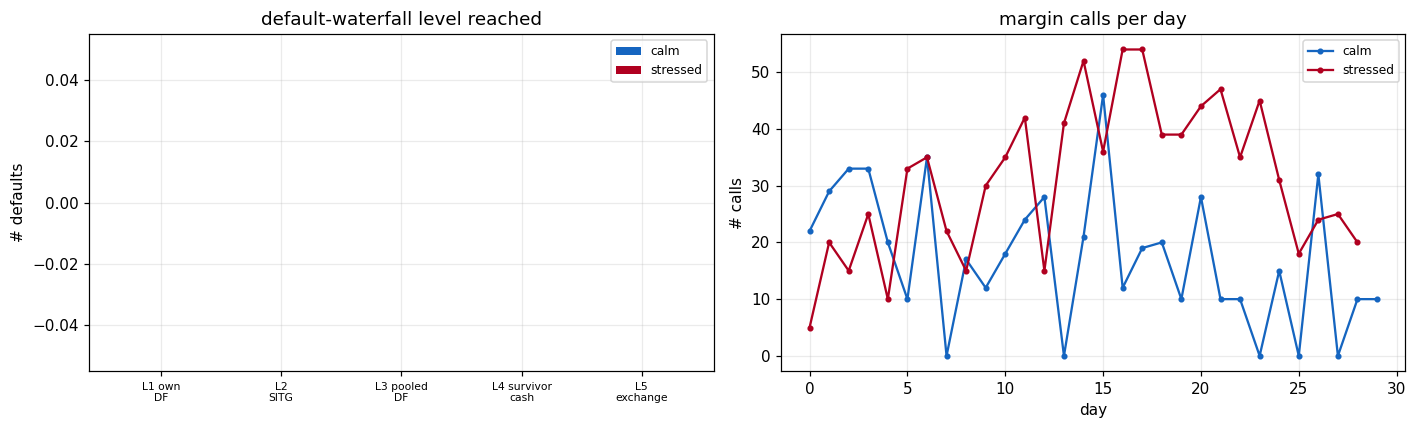

In [24]:
for r in REGIMES:
    cl = SIM[r]["clearing"]; ccp = SIM[r]["ccp"]
    ev = cl[cl.has_defaulted].sort_values("t").groupby("agent_id").first().reset_index()
    print(f"================  {r.upper()}  ================")
    nbcm = int((ev.kind=='NBCM').sum()); nbk = int((ev.kind=='BCM').sum())
    print(f"defaults: {len(ev)}  ({nbk} BCM, {nbcm} NBCM)   "
          f"| cover-2 total_DF ${ccp.total_df/1e9:.1f}B  SITG end ${ccp.own_df/1e9:.2f}B  "
          f"CCP cash end ${ccp.cash/1e9:.2f}B (start $7.5B)")
    if len(ev):
        im = im_fraction(SIGMA_V[r])      # procyclical IM fraction → recover exposure = IM / im
        tbl = pd.DataFrame({
            "CM": ev.agent_id, "kind": ev.kind,
            "default_min": ev.t.astype(int),
            "default_day": day_of(r, ev.t.to_numpy()).astype(int),
            "cap_ratio@def": ev.capital_ratio.round(3),
            "cash@def_$M": (ev.cash/1e6).round(1),
            "own_pos_lots": ev.own_position.astype(int),
            "book_exposure_$B": (ev.initial_margin/im/1e9).round(2),
            "waterfall_lvl": ev.waterfall_level.astype(int),
        }).reset_index(drop=True)
        print(tbl.to_string(index=False))
    print()

# Waterfall-level distribution + margin-call counts, both regimes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r, c in zip(REGIMES, ["#1565c0", "#b00020"]):
    cl = SIM[r]["clearing"]
    lv = cl[cl.waterfall_level>0].waterfall_level.value_counts().reindex([1,2,3,4,5], fill_value=0)
    axes[0].bar(lv.index + (0.18 if r=="stressed" else -0.18), lv.values, 0.36, color=c, label=r)
axes[0].set_xticks([1,2,3,4,5])
axes[0].set_xticklabels(["L1 own\nDF","L2\nSITG","L3 pooled\nDF","L4 survivor\ncash","L5\nexchange"], fontsize=7)
axes[0].set_title("default-waterfall level reached"); axes[0].set_ylabel("# defaults"); axes[0].legend(fontsize=8)
for r, c in zip(REGIMES, ["#1565c0", "#b00020"]):
    cl = SIM[r]["clearing"]
    calls = cl.groupby(day_of(r, cl.t.to_numpy())).call_indicator.sum()
    axes[1].plot(calls.index, calls.values, color=c, marker="o", ms=3, label=r)
axes[1].set_title("margin calls per day"); axes[1].set_xlabel("day"); axes[1].set_ylabel("# calls"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 · Client clearing — the client → CM contagion channel

Each client posts its own variation margin, freezes at the 8% floor, and defaults on
cash exhaustion; its CM then **assumes and Almgren-Chriss-liquidates** the position, the
close-out loss realised by marking it as the fire-sale walks the price (deficit-consistent).
**Left:** client defaults by type over the COVID window — the smaller, thinner-capitalised
accounts fail first while the well-capitalised asset managers withstand the shock. **Right:**
the loss each CM absorbs from its defaulting clients — the cash drain that can push a CM
itself into default. At actual COVID severity the framework contains these defaults (the
CMs absorb them); the reverse-stress subsection below amplifies the shock to locate the
cover-2 breach.

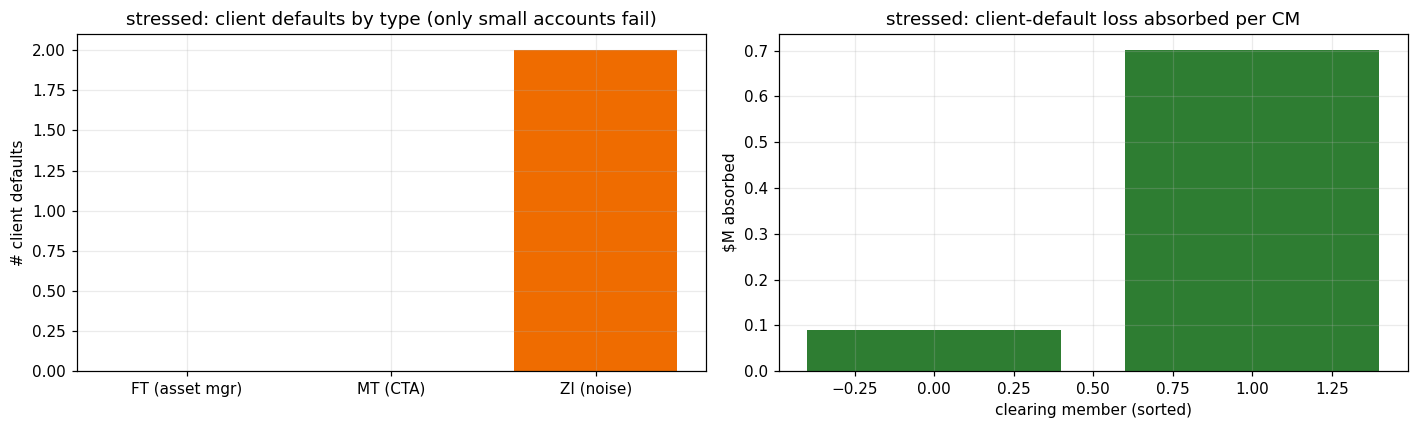

stressed: 2 client defaults | $1M total client-default loss absorbed by CMs


In [25]:
r = "stressed"; ch = pd.DataFrame(SIM[r]["sim"].client_history); cl = SIM[r]["clearing"]
_order = ["FundamentalTrader", "MomentumTrader", "ZeroIntelligenceTrader"]
_short = {"FundamentalTrader": "FT (asset mgr)", "MomentumTrader": "MT (CTA)", "ZeroIntelligenceTrader": "ZI (noise)"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = [int((ch.kind == k).sum()) if len(ch) else 0 for k in _order]
axes[0].bar(range(3), counts, color=["#1565c0", "#2e7d32", "#ef6c00"])
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([_short[k] for k in _order])
axes[0].set_title("stressed: client defaults by type (only small accounts fail)")
axes[0].set_ylabel("# client defaults")
ab = cl.groupby("agent_id").agg(absorbed=("client_loss_absorbed", "sum"),
                                kind=("kind", "first")).reset_index()
ab = ab[ab.absorbed > 0].sort_values("absorbed")
axes[1].bar(range(len(ab)), ab.absorbed/1e6,
            color=["#1565c0" if k == "BCM" else "#2e7d32" for k in ab.kind])
axes[1].set_title("stressed: client-default loss absorbed per CM")
axes[1].set_ylabel("$M absorbed"); axes[1].set_xlabel("clearing member (sorted)")
plt.tight_layout(); plt.show()
nd = ch.client_id.nunique() if len(ch) else 0
tot = (ch.shortfall.sum() + ch.closeout_loss.sum())/1e6 if len(ch) else 0.0
print(f"stressed: {nd} client defaults | ${tot:.0f}M total client-default loss absorbed by CMs")

### Reverse stress — locating the cover-2 breach point (Euronext A9 §5)

At actual COVID severity the cover-2 framework *contains* the cleared book. To find where
it breaks, the **reverse-stress test** amplifies the real COVID path by a multiplier `c`
(Euronext A9 §5 — `covid_contagion.py`) and tracks the deepest waterfall level and the
default counts as `c` rises. Client defaults appear and are **absorbed by their CMs**
across a wide range; cross-member **mutualisation (waterfall Level 4)** — the cash-sharing
contagion step — onsets only under a beyond-COVID shock (~2.5×, the gapped path now carries the
true ≈−33% COVID drawdown), with the CCP solvent and
the default fund at a realistic scale throughout. This quantifies the system's resilience
as a breach multiplier.

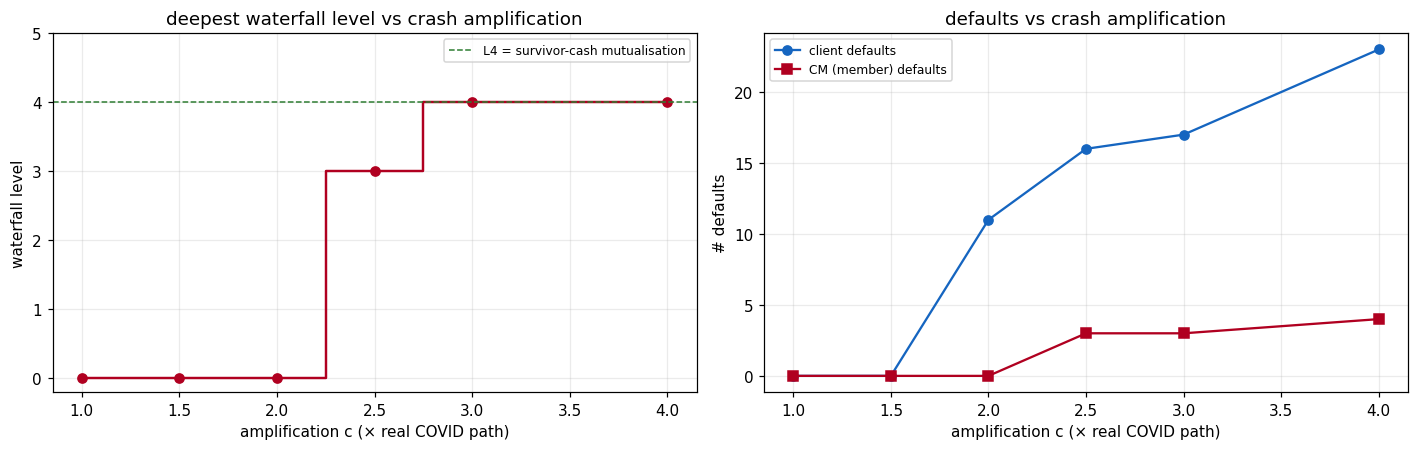

drawdowns: c=1:-19%, c=1.5:-27%, c=2:-34%, c=2.5:-41%, c=3:-46%, c=4:-56%
cover-2 mutualisation (>= L3 pooled DF) onset: c >= 2.5 | CCP cash end $7.41B (start $7.5B)


In [26]:
from covid_contagion import run as covid_run
cs = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
rs = [covid_run(c) for c in cs]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].step(cs, [r["deepest_waterfall"] for r in rs], where="mid", color="#b00020", lw=1.6, marker="o")
axes[0].axhline(4, color="#2e7d32", ls="--", lw=1, label="L4 = survivor-cash mutualisation")
axes[0].set_title("deepest waterfall level vs crash amplification")
axes[0].set_xlabel("amplification c (× real COVID path)"); axes[0].set_ylabel("waterfall level")
axes[0].set_yticks([0, 1, 2, 3, 4, 5]); axes[0].legend(fontsize=8)
axes[1].plot(cs, [r["client_defaults"] for r in rs], color="#1565c0", marker="o", label="client defaults")
axes[1].plot(cs, [r["cm_defaults"] for r in rs], color="#b00020", marker="s", label="CM (member) defaults")
axes[1].set_title("defaults vs crash amplification")
axes[1].set_xlabel("amplification c (× real COVID path)"); axes[1].set_ylabel("# defaults"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
brk = next((c for c, r in zip(cs, rs) if r["deepest_waterfall"] >= 3), None)
print("drawdowns: " + ", ".join(f"c={c:g}:{r['drawdown']:.0f}%" for c, r in zip(cs, rs)))
print("cover-2 mutualisation (>= L3 pooled DF) onset:", (f"c >= {brk:g}" if brk else "not breached"),
      f"| CCP cash end ${rs[-1]['ccp_cash']/1e9:.2f}B (start $7.5B)")

## 9 · Stylised facts (calibration targets)

Simulated vs empirical ES 1-minute returns, presented as in HFABM (2208.13654)
and XGB-Chiarella (2208.14207): the fat-tailed return distribution and the Hill
tail index, then three autocorrelation functions — of **returns**, **absolute
returns** and **squared returns** — as offset stems overlaying empirical (red)
against simulated (blue), with the ±1.96/√N band. Returns show near-zero linear
autocorrelation (the price is close to a martingale); absolute and squared
returns show slowly-decaying positive autocorrelation = **volatility clustering**.

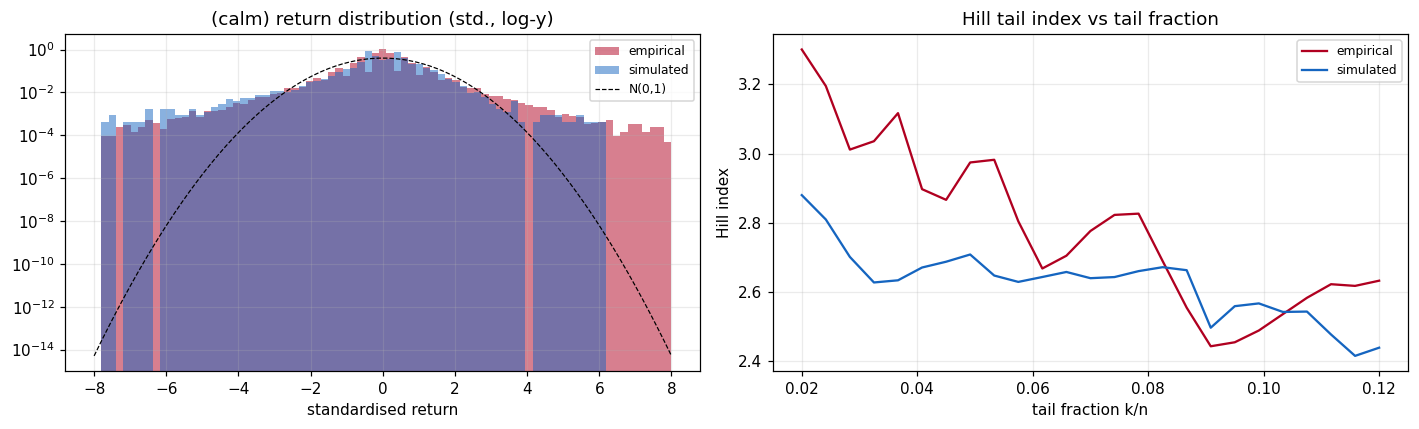

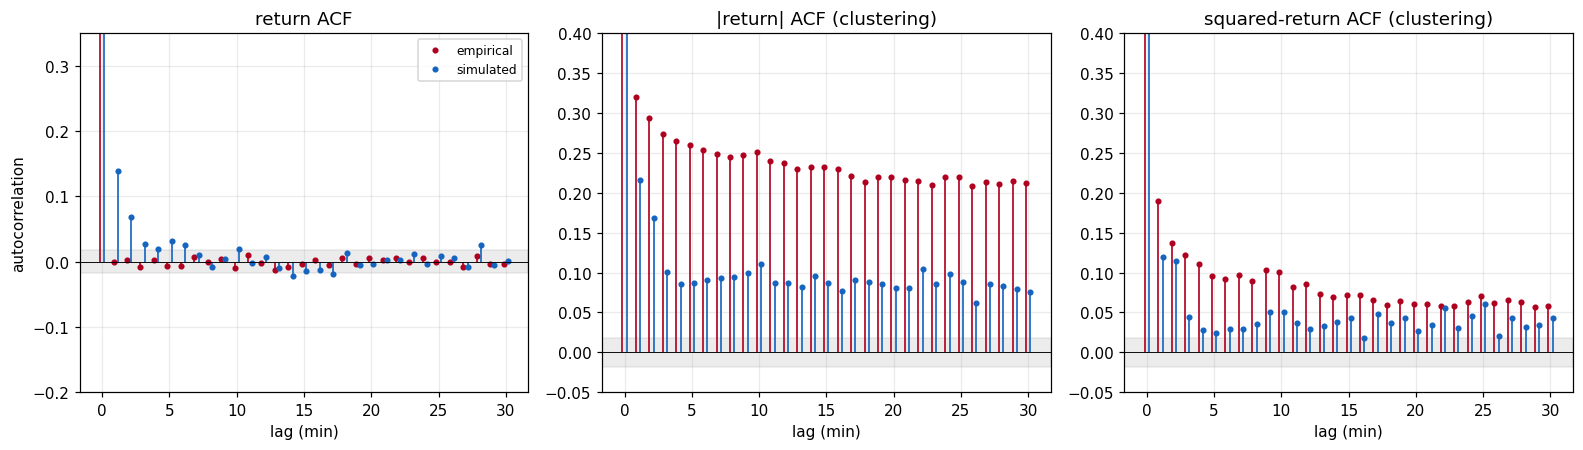

calm: sim kurtosis 11.7  empirical 19.9


In [27]:
def acf(x, nlags):
    x = x - x.mean(); v = x.dot(x)
    return np.array([1.0] + [x[:-k].dot(x[k:])/v for k in range(1, nlags+1)])
def hill_curve(x, fracs=np.linspace(0.02, 0.12, 25)):
    a = np.sort(np.abs(x))[::-1]; n = len(a); out = []
    for f in fracs:
        k = max(5, int(f*n)); xi = np.mean(np.log(a[:k])) - np.log(a[k])
        out.append(1.0/xi if xi > 0 else np.nan)
    return fracs, np.array(out)
def acf_stem(ax, x, nlags, color, label, off=0.0):
    a = acf(x, nlags); lags = np.arange(nlags+1) + off
    ax.vlines(lags, 0, a, color=color, alpha=0.85, lw=1.3)
    ax.plot(lags, a, "o", color=color, ms=3, label=label)

r = "calm"; s, e = RET[r], EMP[r]; ss, es = s/s.std(), e/e.std()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(-8, 8, 80)
axes[0].hist(es, bins=bins, density=True, alpha=0.5, color="#b00020", label="empirical")
axes[0].hist(ss, bins=bins, density=True, alpha=0.5, color="#1565c0", label="simulated")
axes[0].plot(bins, np.exp(-bins**2/2)/np.sqrt(2*np.pi), "k--", lw=0.8, label="N(0,1)")
axes[0].set_yscale("log"); axes[0].set_title(f"({r}) return distribution (std., log-y)")
axes[0].set_xlabel("standardised return"); axes[0].legend(fontsize=8)
fe, he = hill_curve(e); fs, hs = hill_curve(s)
axes[1].plot(fe, he, color="#b00020", label="empirical"); axes[1].plot(fs, hs, color="#1565c0", label="simulated")
axes[1].set_title("Hill tail index vs tail fraction"); axes[1].set_xlabel("tail fraction k/n")
axes[1].set_ylabel("Hill index"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ACF stems, empirical (red) vs simulated (blue) overlaid on shared axes
# (XGB-Chiarella 2208.14207): returns / |returns| / squared returns.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharex=True)
L = 30; ci = 1.96/np.sqrt(len(s))   # 95% band at the (shorter) simulated length
series = [(e, s, "return ACF", (-0.2, 0.35)),
          (np.abs(e), np.abs(s), "|return| ACF (clustering)", (-0.05, 0.4)),
          (e**2, s**2, "squared-return ACF (clustering)", (-0.05, 0.4))]
for ax, (ev, sv, title, yl) in zip(axes, series):
    acf_stem(ax, ev, L, "#b00020", "empirical", off=-0.16)
    acf_stem(ax, sv, L, "#1565c0", "simulated", off=+0.16)
    ax.axhspan(-ci, ci, color="grey", alpha=0.15); ax.axhline(0, color="k", lw=0.6)
    ax.set_title(title); ax.set_ylim(*yl); ax.set_xlabel("lag (min)")
axes[0].set_ylabel("autocorrelation"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"{r}: sim kurtosis {((s/s.std())**4).mean()-3:.1f}  empirical {((e/e.std())**4).mean()-3:.1f}")

## 10 · Calibration methodology and alternatives considered

**Style.** Behavioural parameters are fit by *simulated method of moments* — choose θ so
the simulated 1-minute return moments match the empirical ES moments. The target battery
is the Cont (2001) stylised-fact set; the loss is a **five-component standardised-moment
distance**, each component divided by its empirical block-bootstrap sampling SD
(Franke & Westerhoff 2012) so heterogeneous moments are commensurable:

| component | matches | source |
|---|---|---|
| KS | whole return distribution (2-sample Kolmogorov–Smirnov) | XGB-Chiarella §3.2.4 |
| V | return standard deviation | Gao et al. 2022 |
| ACF1 | autocorrelation of returns, lags {1, 5, 10, 20} | Cont 2001 |
| ACF2 | autocorrelation of \|returns\| (clustering), lags {1, 5, 10, 20} | Cont 2001 / 2005 |
| Hill | tail index (banded) | HFABM §4.1.1 |

Excess kurtosis is a diagnostic only (outlier-dominated). KS and Hill are deliberately
paired — KS pins the distribution body, Hill the tail.

**Two solvers, reported together (the cross-check).**

1. **Surrogate-assisted SMM** (`calibrate.py run`; XGB-Chiarella / Gao et al. 2022). The
   simulator is expensive, so we sample θ on a Latin-hypercube design, fit a single
   **XGBoost** regressor θ → D(θ) as a cheap surrogate, run a few rounds of greedy active
   learning (more simulator runs where the surrogate predicts low loss), minimise D on the
   surrogate (pool argmin over a Sobol candidate set), then refine on the *true* simulator
   in a tight box and validate on fresh seeds — ~200 true-simulator evaluations.
2. **Exhaustive grid search** (`calibrate.py grid`; Gao et al. 2023 "Deeper Hedging" /
   Chiarella–Heston §3.3). True loss on a regular grid over the regime box; take the
   minimum. Transparent and exhaustive — defensible at this low dimension (calm 3-d,
   stressed 4-d) — and it yields the full loss surface.

Both are from the same research group and should agree on θ\*; the grid is the
easy-to-defend headline, the surrogate shows efficient convergence. Regime-specific set:
calm `{ft_sigma_c, zi_alpha, zi_delta}`, stressed `{+ p_zi}`; `zi_mu` pinned at the
Cont-Stoikov baseline. *(The population was just doubled and a 5-min lag added to ACF1,
so both solvers are being re-run; the values shown above are interim.)*

### Alternatives considered

**Fundamental — a jump-diffusion stochastic-volatility path (`data/v_gbm.py`).** Before
the Kalman fundamental we used a synthetic **Stein–Stein/Heston stochastic-volatility
Merton-jump-diffusion**: a GBM whose instantaneous volatility mean-reverts (Vasicek/OU)
with overlaid Poisson jumps —

```
σ_{t+1}             = θ + e^(−α)(σ_t − θ) + s·Z_σ                  (Vasicek–OU vol)
log V_{t+1}−log V_t = (μ − ½σ_t²) + σ_t·Z + J,  J ~ N(0, δ²) w.p. λ/390   (Merton jumps)
```

with diffusion/jump parameters from ES return variance and excess kurtosis, OU from a
30-minute realised-vol series, and λ = 3/day (the ODD value). It is **kept as a robustness
alternative**, but the ablation showed the **Kalman efficient price fits better in both
regimes once the tail is controlled, and is far more defensible** — it is the *real*
return path, with no synthetic jump/vol parameters to justify and no risk of "injecting
the clustering you claim to reproduce."

**Agents tried and removed (ablation).** A mid-anchored *market maker* (HFABM §3.6) —
removed; it damped volatility and clustering without improving the tail. A *volatility
trader* (Gao 2023) — helps the stressed tail but harms calm, so held as a regime-specific
option, not a standing agent. A *Cont (2005) threshold trader* — no durable clustering
gain. *Power-law (Pareto) order sizes* — degraded the tail under the linear-impact LOB
(volume scale is instead handled by the `VOLUME_LOT` relabel). The *placement law* was
reverted from a calibrated log-normal to a **data-fit geometric** depth grounded in
measured L2 book depth. `ft_sigma_c` was the single dominant lever on the return tail.

| group | parameter | how set |
|---|---|---|
| fundamental | Kalman `μ, σ_v, σ_ε`, local vol `σ_t` | MLE on the ES mid (SV-MJD path kept as alternative) |
| placement | `p_zi` | L2 book depth (calm fixed; stressed calibrated) |
| FT | `ft_sigma_c` | grid/surrogate (the dominant tail lever) |
| ZI | `zi_alpha, zi_delta` | grid/surrogate |
| clearing margins / DF | procyclical VaR IM (≈6%/12%, EMIR Art.41/CME SPAN); cash/IM capital floor 8% (CFTC Reg 1.17); cover-2 SLOIM DF + 10% buffer (Euronext A9); SITG 10%; deficit waterfall; BCM VaR house limit 5% (FRTB) |
| cash | BCM / NBCM / CCP / clients | CFTC FCM + LCH disclosures; clients by entity type |

## 11 · Summary

The market layer reproduces the ES stylised facts (fat tails — calm Hill ≈ 3.0, matching the
empirical tail index ≈2.96; near-zero return autocorrelation; short-horizon volatility
clustering) under both regimes, calibrated by two cross-validating methods. (Kurtosis is
tracked as a diagnostic only — it is dominated by a handful of extremes and runs above
empirical; Hill is the tail measure the loss actually targets, and it matches.) On top
of it the clearing layer runs **real margin methodology**: procyclical VaR/SPAN initial
margin, a cash/IM capital ratio (CFTC Reg 1.17), a cover-2 Stress-Loss-Over-Initial-Margin
default fund (Euronext A9), a deficit-based five-level waterfall, Almgren-Chriss
deleveraging / fire-sales, and a VaR house limit on banking-CM prop books. The
**client-clearing tier** is the contagion channel: 90 clients post their own margin,
freeze at the 8% floor, and default on cash exhaustion, on which their CM assumes and
liquidates the position. On the real COVID window the cover-2 framework **contains** the
book — defaults are absorbed by the defaulter's own resources — and a reverse-stress sweep
locates the **cover-2 breach** (cross-member mutualisation onsets only at a beyond-COVID
≈2.5× shock, CCP solvent throughout): the framework behaves as a sound CCP should.

Remaining items: long-horizon volatility clustering (a single-timescale momentum limit);
running the contagion outcomes as **Monte-Carlo ensembles over seeds** (distributions of
the breach multiplier, default count, waterfall depth, mutualised loss) and designed sweeps
over CM count / client-book concentration / margin methodology; and final calibrated
parameters from the running grid + surrogate re-calibration of the doubled population.